___________________________________
# Medical Insurance Cost Prediction

## Tools Used

- Python
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-Learn

## Machine Learning Models

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

## Project Objective

The objective of this project is to analyze medical insurance data and build machine learning models to predict insurance charges. The project compares multiple regression algorithms and identifies the best-performing model based on evaluation metrics.
___________________________________

___________________________________
## Initial Observation

- Dataset contains medical insurance customer information.
- Target variable is Charges.
- Charges represent the medical insurance cost.
- Dataset includes demographic and health-related features such as age, BMI, smoking status, region, and number of children.
- The objective is to predict insurance charges using machine learning regression models.
___________________________________

___________________________________
## SECTION 1 — Import Libraries
* Importing required Python libraries for data analysis and visualization.
___________________________________

In [1]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

___________________________________
## SECTION 2 — Load Dataset
* Loading the medical insurance dataset into pandas DataFrame.
___________________________________

In [2]:
# Load Dataset

df = pd.read_csv('../Dataset/medical_insurance.csv')

___________________________________
## SECTION 3 — Dataset Overview
* Understanding dataset structure, shape, columns, info and basic statistics.
___________________________________

In [3]:
# Display Dataset

df.head()

,patient_id,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category
0,101,19,female,27.90,0,yes,southwest,16884.92,Young,Overweight
1,102,18,male,33.77,1,no,southeast,1725.55,Young,Obese
2,103,28,male,33.00,3,no,southeast,4449.46,Young,Obese
3,104,33,male,22.71,0,no,northwest,21984.47,Adult,Normal
4,105,32,male,28.88,0,no,northwest,3866.86,Adult,Overweight


In [4]:
# Dataset Shape

df.shape

(1338, 10)

In [5]:
# Column Names

df.columns

Index(['patient_id', 'age', 'sex', 'bmi', 'children', 'smoker', 'region',
       'charges', 'age_group', 'bmi_category'],
      dtype='object')

_____________________________________________
## Important Thing 

In Machine Learning training:

we will not use patient_id.

Because:

* it is only an ID
* it does not help in prediction

Later:

df.drop("patient_id", axis=1)

we will remove it.
_____________________________________________

In [6]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    1338 non-null   int64  
 1   age           1338 non-null   int64  
 2   sex           1338 non-null   object 
 3   bmi           1338 non-null   float64
 4   children      1338 non-null   int64  
 5   smoker        1338 non-null   object 
 6   region        1338 non-null   object 
 7   charges       1338 non-null   float64
 8   age_group     1338 non-null   object 
 9   bmi_category  1338 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 104.7+ KB


In [7]:
# Statistical Summary

df.describe().round(2)

,patient_id,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00,1338.00
mean,769.50,39.21,30.66,1.09,13270.42
std,386.39,14.05,6.10,1.21,12110.01
min,101.00,18.00,15.96,0.00,1121.87
25%,435.25,27.00,26.30,0.00,4740.29
50%,769.50,39.00,30.40,1.00,9382.03
75%,1103.75,51.00,34.70,2.00,16639.92
max,1438.00,64.00,53.13,5.00,63770.43


___________________________________
## SECTION 4 — Data Quality Check
* Checking missing values and duplicate records in the dataset.
___________________________________

In [8]:
# Check Missing Values

df.isnull().head(10)

,patient_id,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False


In [9]:
df.isnull().sum()

patient_id      0
age             0
sex             0
bmi             0
children        0
smoker          0
region          0
charges         0
age_group       0
bmi_category    0
dtype: int64

In [10]:
# Check Duplicate Values

df.duplicated().sum()

np.int64(0)

___________________________________
# SECTION 5 — Exploratory Data Analysis (EDA)
* Performing exploratory data analysis to identify patterns, distributions, trends, and relationships in the medical insurance dataset.
___________________________________

___________________________________
### Unique Values Analysis
* #### Unique Values in Categorical Columns
    * Checking unique categories present in categorical columns.
___________________________________

In [11]:
df['sex'].unique()

array(['female', 'male'], dtype=object)

In [12]:
df['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [13]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [14]:
df['age_group'].unique()

array(['Young', 'Adult', 'Senior'], dtype=object)

In [15]:
df['bmi_category'].unique()

array(['Overweight', 'Obese', 'Normal', 'Underweight'], dtype=object)

___________________________________
### Value Counts
* #### Category Counts
    * Analyzing the distribution of categorical variables.
___________________________________

In [16]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [17]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [18]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

___________________________________
### Now Visualization the Data
* #### 1. Smoker Distribution Visualization
    * Visualizing smoker and non-smoker distribution using Seaborn countplot.
___________________________________

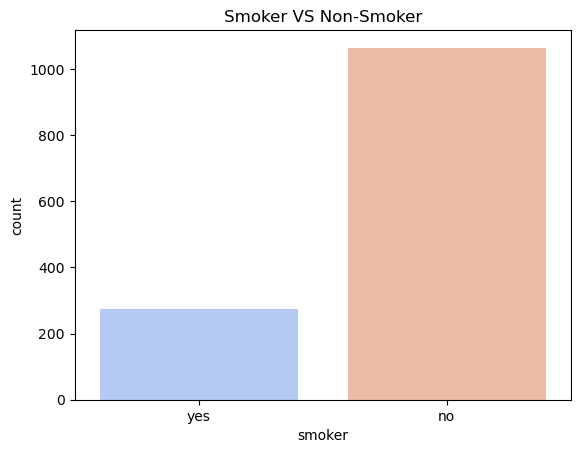

In [19]:
sns.countplot(x='smoker', data= df, hue= 'smoker', palette='coolwarm')

plt.title('Smoker VS Non-Smoker')
plt.show()

___________________________________
#### 2. Gender Distribution Visualization
Visualizing the distribution of male and female patients in the dataset.
___________________________________

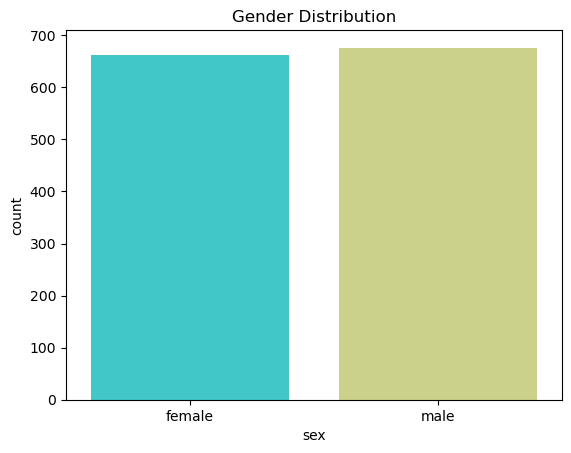

In [20]:
sns.countplot(x='sex', data= df, hue= 'sex', palette= 'rainbow')

plt.title('Gender Distribution')
plt.show()

___________________________________
#### 3. Region Distribution Visualization 
Analyzing patient distribution across different regions.
___________________________________

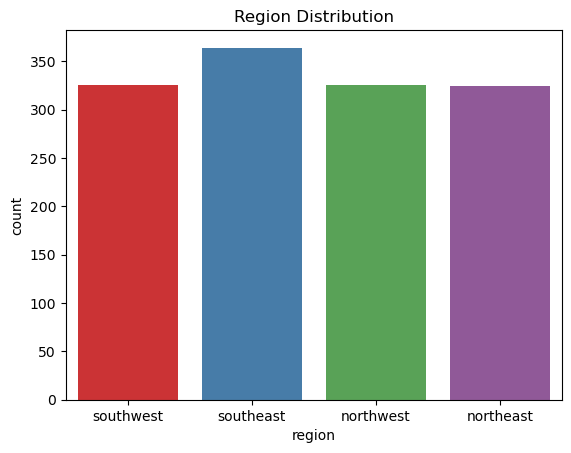

In [21]:
sns.countplot(x= 'region', data= df, hue= 'region', palette= 'Set1')

plt.title('Region Distribution')
plt.show()

___________________________________
#### 4. BMI Distribution
Visualizing the distribution of BMI values using histogram.
___________________________________

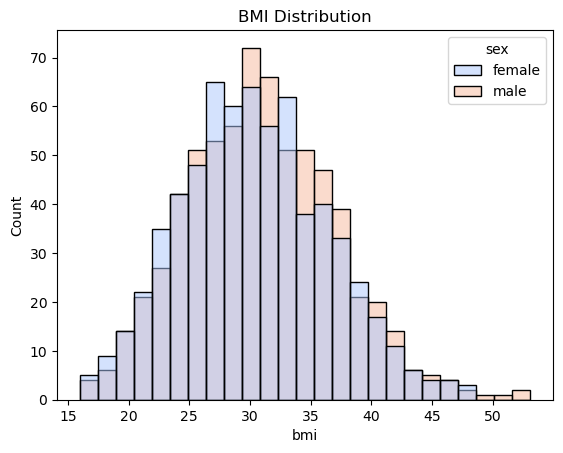

In [22]:
sns.histplot(x= 'bmi', data= df, hue= 'sex', palette= 'coolwarm')

plt.title('BMI Distribution')
plt.show()

___________________________________
#### 5. Insurance Charges Distribution
Analyzing the distribution of insurance charges.
___________________________________

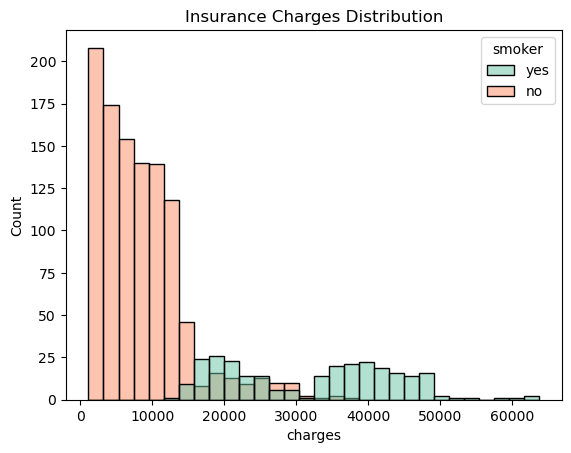

In [23]:
sns.histplot(x= 'charges', data= df, hue= 'smoker', palette= 'Set2')
plt.title('Insurance Charges Distribution')
plt.show()

___________________________________
#### 6. Age vs Insurance Charges
Analyzing the relationship between age and insurance charges.
___________________________________

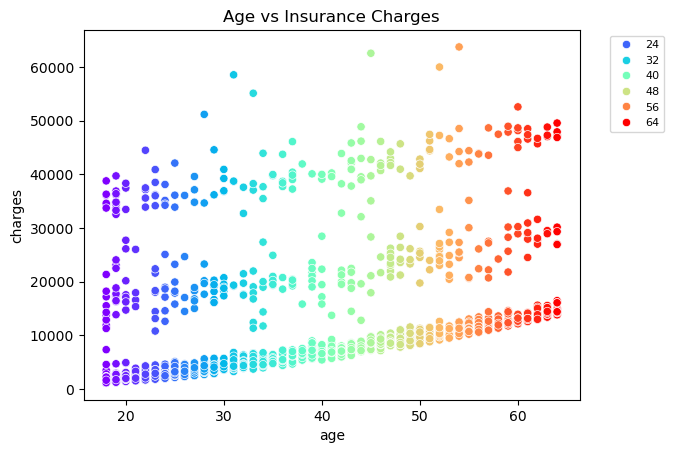

In [24]:
sns.scatterplot(x= 'age', y= 'charges', data= df, hue= 'age', palette= 'rainbow')

plt.title('Age vs Insurance Charges')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.show()

___________________________________
#### 7. Smoker vs Insurance Charges
Analyzing how smoking affects insurance charges.
___________________________________

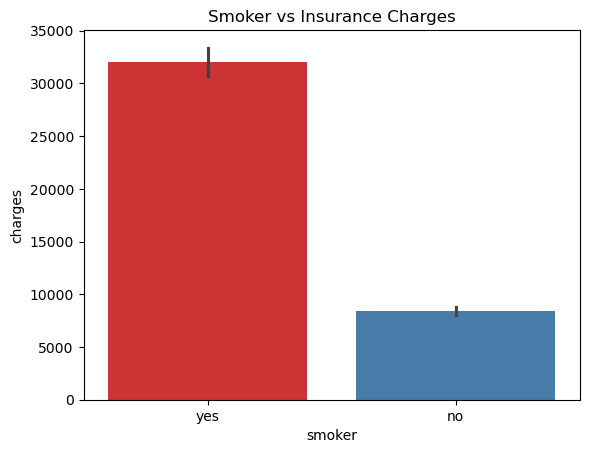

In [25]:
sns.barplot(x= 'smoker', y= 'charges', data= df, hue= 'smoker', palette= 'Set1')

plt.title('Smoker vs Insurance Charges')
plt.show()

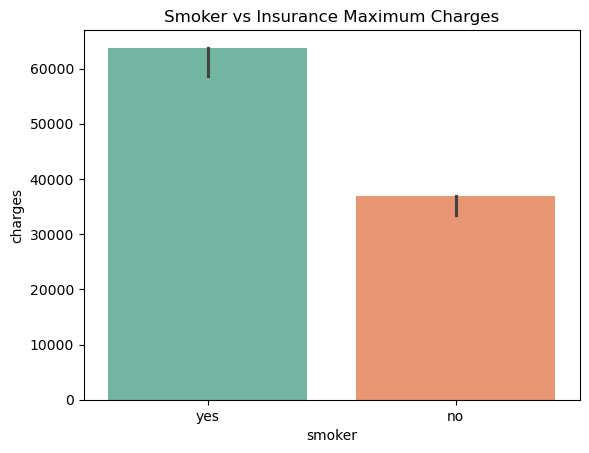

In [26]:
sns.barplot(x='smoker', y='charges', data=df, estimator=max, hue='smoker', palette='Set2')

plt.title('Smoker vs Insurance Maximum Charges')
plt.show()

___________________________________
#### 8. BMI Category vs Insurance Charges
Analyzing insurance charges across different BMI categories.
___________________________________

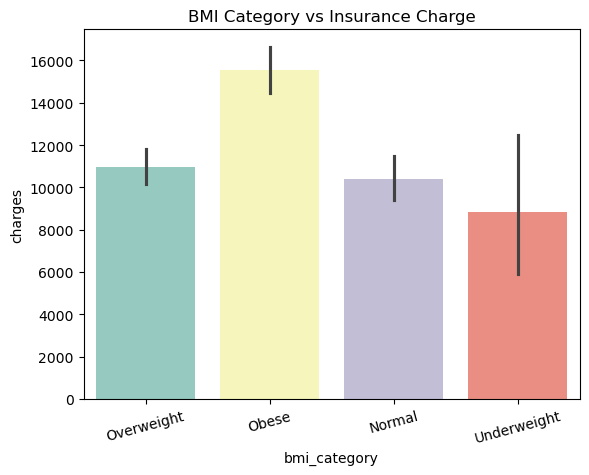

In [27]:
sns.barplot(x= 'bmi_category', y= 'charges', data= df, hue= 'bmi_category', palette= 'Set3')

plt.title('BMI Category vs Insurance Charge')
plt.xticks(rotation= 15)
plt.show()

___________________________________
#### 9. Age Group vs Insurance Charges
Analyzing insurance charges across different age groups.
___________________________________

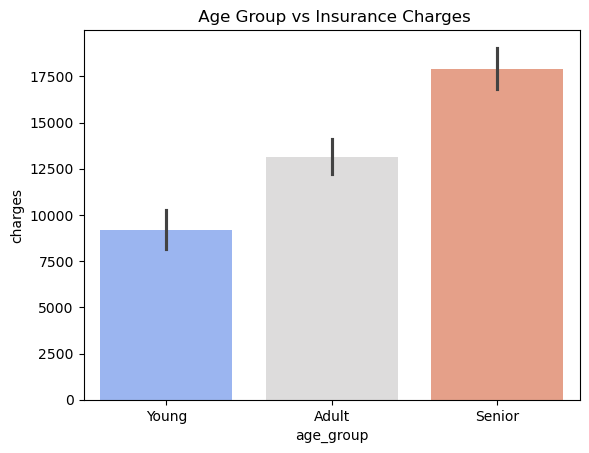

In [28]:
sns.barplot(x= 'age_group', y= 'charges', data= df, hue= 'age_group', palette= 'coolwarm')

plt.title(' Age Group vs Insurance Charges')
plt.show()

___________________________________
#### 10. Correlation Heatmap
Visualizing relationships between numerical variables using correlation heatmap.
___________________________________

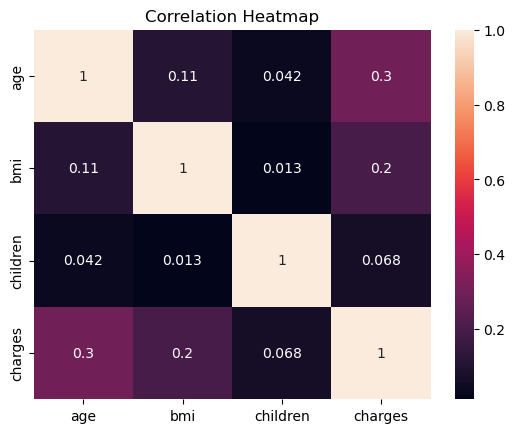

In [41]:
numeric_df = df.select_dtypes(include=['number'])
correlation = numeric_df.corr()

sns.heatmap(correlation, annot=True)

plt.title("Correlation Heatmap")
plt.show()

___________________________________
#### 11. Charges Boxplot
Detecting outliers in insurance charges using boxplot.
___________________________________

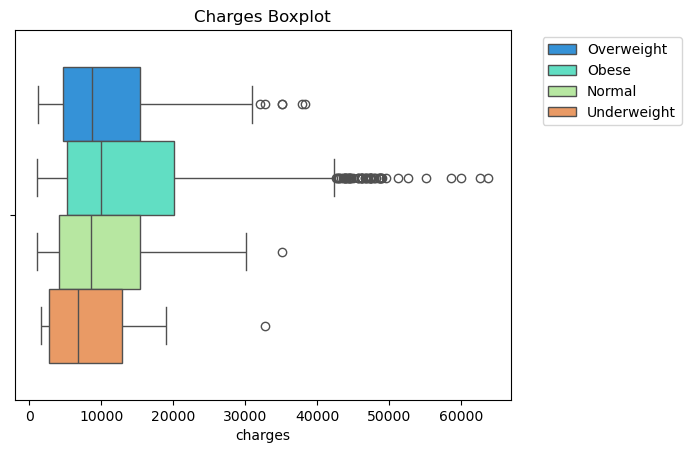

In [29]:
sns.boxplot(x= 'charges', data=df, hue='bmi_category', palette='rainbow')

plt.title('Charges Boxplot')
plt.legend(bbox_to_anchor= (1.05,1), loc='upper left', fontsize= 10)

plt.show()

___________________________________
# SECTION 6 — NumPy Analysis 🔥

* ## NumPy Statistical Analysis
    * Performing numerical and statistical analysis using NumPy.
___________________________________

___________________________________
### Average Insurance Charges
Calculating average insurance charges using NumPy.
___________________________________

In [30]:
np.mean(df['charges']).round(2)

np.float64(13270.42)

___________________________________
### Median Insurance Charges
Calculating median insurance charges.
___________________________________

In [31]:
round(np.median(df['charges']),2)

np.float64(9382.03)

___________________________________
### Standard Deviation of Charges
Measuring variability in insurance charges.
___________________________________

In [32]:
round(np.std(df['charges']),2)

12105.48

___________________________________
### Minimum and Maximum Charges
Finding minimum and maximum insurance charges.
___________________________________

In [33]:
np.max(df['charges'])

63770.43

In [34]:
np.min(df['charges'])

1121.87

___________________________________
## Percentile Analysis
Calculating percentiles for insurance charges distribution.
___________________________________

In [35]:
np.percentile(df['charges'],25).round(2)

np.float64(4740.29)

In [36]:
np.percentile(df['charges'], 50).round(2)

np.float64(9382.03)

In [37]:
round(np.percentile(df['charges'],75) ,2)

np.float64(16639.92)

___________________________________
# SECTION 7 — Data Preprocessing 

* ### Data Preprocessing
    * Preparing the dataset for machine learning model training.
___________________________________

___________________________________
## Drop Unnecessary Columns
Removing columns that are not useful for prediction.
_____________________________________________
In Machine Learning training:- we will not use patient_id.

* Because:
    * it is only an ID
    * it does not help in prediction
    * so we will remove it.
___________________________________

In [38]:
df.head()

,patient_id,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category
0,101,19,female,27.90,0,yes,southwest,16884.92,Young,Overweight
1,102,18,male,33.77,1,no,southeast,1725.55,Young,Obese
2,103,28,male,33.00,3,no,southeast,4449.46,Young,Obese
3,104,33,male,22.71,0,no,northwest,21984.47,Adult,Normal
4,105,32,male,28.88,0,no,northwest,3866.86,Adult,Overweight


In [39]:
df = df.drop('patient_id', axis=1)

In [40]:
# Checking dataset after removing unnecessary columns.

df.head()

,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category
0,19,female,27.90,0,yes,southwest,16884.92,Young,Overweight
1,18,male,33.77,1,no,southeast,1725.55,Young,Obese
2,28,male,33.00,3,no,southeast,4449.46,Young,Obese
3,33,male,22.71,0,no,northwest,21984.47,Adult,Normal
4,32,male,28.88,0,no,northwest,3866.86,Adult,Overweight


___________________________________
## Encode Categorical Variables
Converting categorical columns into numerical format using one-hot encoding.
___________________________________

In [42]:
df = pd.get_dummies(df, drop_first=True, dtype=int)

In [43]:
# Displaying dataset after categorical encoding.

df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,age_group_Senior,age_group_Young,bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight
0,19,27.90,0,16884.92,0,1,0,0,1,0,1,0,1,0
1,18,33.77,1,1725.55,1,0,0,1,0,0,1,1,0,0
2,28,33.00,3,4449.46,1,0,0,1,0,0,1,1,0,0
3,33,22.71,0,21984.47,1,0,1,0,0,0,0,0,0,0
4,32,28.88,0,3866.86,1,0,1,0,0,0,0,0,1,0


___________________________________
## Feature and Target Variables Split
Separating independent variables and target variable.
___________________________________

In [44]:
x = df.drop('charges', axis=1)

y = df['charges']

In [45]:
# Checking feature variables and target variable.

x.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,age_group_Senior,age_group_Young,bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight
0,19,27.90,0,0,1,0,0,1,0,1,0,1,0
1,18,33.77,1,1,0,0,1,0,0,1,1,0,0
2,28,33.00,3,1,0,0,1,0,0,1,1,0,0
3,33,22.71,0,1,0,1,0,0,0,0,0,0,0
4,32,28.88,0,1,0,1,0,0,0,0,0,1,0


In [46]:
# Checking feature variables and target variable.

y.head()

0    16884.92
1     1725.55
2     4449.46
3    21984.47
4     3866.86
Name: charges, dtype: float64

___________________________________
# SECTION 8 — Machine Learning Model

* ### Machine Learning Model
    * Training a machine learning model to predict medical insurance charges.
___________________________________

___________________________________
## Train Test Split
Splitting the dataset into training and testing sets.
___________________________________

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)

___________________________________
## Training and Testing Data Shapes
Checking the dimensions of training and testing datasets.
___________________________________

In [49]:
x_train.shape

(1070, 13)

In [50]:
x_test.shape

(268, 13)

In [51]:
y_train.shape

(1070,)

In [52]:
y_test.shape

(268,)

___________________________________
# Import Linear Regression Model
Importing Linear Regression algorithm from scikit-learn.
___________________________________

In [53]:
from sklearn.linear_model import LinearRegression

___________________________________
## Create Linear Regression Model
Creating the Linear Regression model object.
___________________________________

In [54]:
model = LinearRegression()

___________________________________
## Train the Model
Training the Linear Regression model using training data.
___________________________________

In [55]:
model.fit(x_train, y_train)

LinearRegression()

___________________________________
## Make Predictions
Predicting insurance charges using the trained model.
___________________________________

In [56]:
predictions = model.predict(x_test)

___________________________________
## Predicted Values
Displaying predicted insurance charges.
___________________________________

In [57]:
predictions[:5]

array([ 8147.69079386,  7777.86768597, 36608.92205097,  8546.3592366 ,
       28554.73904939])

___________________________________
# SECTION 9 — Model Evaluation

* ### Model Evaluation
    * Evaluating the performance of the Linear Regression model.
___________________________________

___________________________________
## Import Evaluation Metrics
Importing model evaluation metrics from scikit-learn.
___________________________________

In [58]:
from sklearn import metrics

___________________________________
### Mean Absolute Error (MAE)
Calculating average prediction error.
___________________________________

In [59]:
mae = round(metrics.mean_absolute_error(y_test, predictions),2)

mae

4283.3

___________________________________
### Mean Squared Error (MSE)
Calculating squared prediction error.
___________________________________

In [60]:
mse = round(metrics.mean_squared_error(y_test, predictions),2)

mse

33450528.37

___________________________________
### Root Mean Squared Error (RMSE)
Calculating root mean squared error for model evaluation.
___________________________________

In [61]:
rmse = round(np.sqrt(metrics.mean_squared_error(y_test, predictions)),2)

rmse

np.float64(5783.64)

___________________________________
### R² Score
Measuring the accuracy of the Linear Regression model.
___________________________________

In [62]:
r2 = metrics.r2_score(y_test, predictions)

r2

0.7845359020829972

In [63]:
from sklearn import metrics

print(round(metrics.mean_absolute_error(y_test, predictions),2))
print(round(metrics.mean_squared_error(y_test, predictions),2))
print(round(np.sqrt(metrics.mean_squared_error(y_test, predictions)),2))
print(metrics.r2_score(y_test, predictions))

4283.3
33450528.37
5783.64
0.7845359020829972


___________________________________
# SECTION 10 — Model Interpretation 
* ### Model Interpretation
    * Understanding how different features impact insurance charges prediction.
___________________________________

___________________________________
## Feature Coefficients
Analyzing the impact of features on insurance charges prediction.
___________________________________

In [64]:
coefficients = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,age,278.727088
1,bmi,87.384228
2,children,546.687633
3,sex_male,-42.120118
4,smoker_yes,23686.006780
5,region_northwest,-434.435171
6,region_southeast,-494.325462
7,region_southwest,-804.465334
8,age_group_Senior,857.793203
9,age_group_Young,1705.315171


___________________________________
## Sorted Feature Importance
Sorting features based on their impact on prediction.
___________________________________

In [65]:
coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
4,smoker_yes,23686.006780
10,bmi_category_Obese,3577.827015
9,age_group_Young,1705.315171
8,age_group_Senior,857.793203
2,children,546.687633
11,bmi_category_Overweight,334.235555
0,age,278.727088
1,bmi,87.384228
3,sex_male,-42.120118
5,region_northwest,-434.435171


___________________________________
## Feature Importance Visualization
Visualizing feature coefficients using barplot.
___________________________________

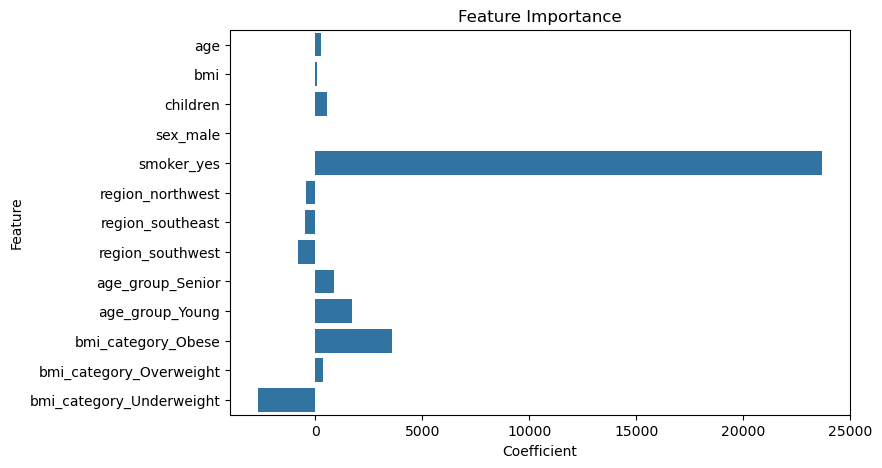

In [66]:
plt.figure(figsize=(8,5))

sns.barplot(x='Coefficient', y='Feature', data= coefficients)
plt.title('Feature Importance')

plt.show()

___________________________________
# SECTION 11 — Advanced Regression Models

* ### Advanced Regression Models
    * Training and comparing advanced machine learning regression models for insurance cost prediction.
___________________________________

___________________________________
# Import Decision Tree and Random Forest Models
Importing advanced regression models from scikit-learn.
___________________________________

In [67]:
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

___________________________________
# Decision Tree Regressor
Training a Decision Tree model for insurance cost prediction.
___________________________________

In [68]:
dt_model = DecisionTreeRegressor(random_state=42)

In [69]:
dt_model.fit(x_train, y_train)

DecisionTreeRegressor(random_state=42)

___________________________________
## Decision Tree Predictions
Generating predictions using Decision Tree Regressor.
___________________________________

In [70]:
dt_predictions = dt_model.predict(x_test)

___________________________________
## Decision Tree Model Evaluation
Evaluating Decision Tree model performance.
___________________________________

In [71]:
dt_mae = round(metrics.mean_absolute_error(y_test, dt_predictions),2)
dt_mse = round(metrics.mean_squared_error(y_test, dt_predictions),2)
dt_rmse = round(np.sqrt(metrics.mean_squared_error(y_test, dt_predictions)),2)
dt_r2 = metrics.r2_score(y_test, dt_predictions)

In [72]:
print("Decision Tree MAE:", dt_mae)
print("Decision Tree MSE:", dt_mse)
print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree R² Score", dt_r2) 

Decision Tree MAE: 3281.95
Decision Tree MSE: 47945356.25
Decision Tree RMSE: 6924.26
Decision Tree R² Score 0.691170709767203


___________________________________
# Random Forest Regressor
Training a Random Forest model for insurance cost prediction.
___________________________________

In [73]:
rf_model = RandomForestRegressor(n_estimators= 100, random_state= 42)

In [74]:
rf_model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

___________________________________
## Random Forest Predictions
Generating predictions using Random Forest Regressor.
___________________________________

In [75]:
rf_predictions = rf_model.predict(x_test)

___________________________________
## Random Forest Model Evaluation
Evaluating Random Forest model performance.
___________________________________

In [76]:
rf_mae = round(metrics.mean_absolute_error(y_test, rf_predictions),2)
rf_mse = round(metrics.mean_squared_error(y_test, rf_predictions),2)
rf_rmse = round(np.sqrt(metrics.mean_squared_error(y_test, rf_predictions)),2)
rf_r2 = metrics.r2_score(y_test, rf_predictions)

In [77]:
print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R² Score:",  rf_r2)

Random Forest MAE: 2600.44
Random Forest MSE: 21624007.59
Random Forest RMSE: 4650.16
Random Forest R² Score: 0.8607137909030741


___________________________________
# Model Comparison
Comparing the performance of different regression models.
___________________________________

In [78]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [mae, dt_mae, rf_mae],
    'MSE': [mse, dt_mse, rf_mse],
    'RMSE': [rmse, dt_rmse, rf_rmse],
    'R² Score': [r2, dt_r2, rf_r2]
})

comparison = comparison.round(2)

comparison

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,4283.30,33450528.37,5783.64,0.78
1,Decision Tree,3281.95,47945356.25,6924.26,0.69
2,Random Forest,2600.44,21624007.59,4650.16,0.86


___________________________________
## Best Performing Model
Identifying the best regression model based on performance metrics.

* **Insight**
    * Random Forest Regressor achieved the best prediction performance among all models with the highest R² Score and lowest prediction error.
___________________________________

___________________________________
# SECTION 12 — Model Visualization

* #### Model Visualization
    * Visualizing model predictions and comparing machine learning model performance.
___________________________________

___________________________________
## Compare Actual vs Predicted Values
Comparing actual and predicted insurance charges.
___________________________________

In [79]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rf_predictions
})

results.head()

,Actual,Predicted
764,9095.07,10809.6984
887,5272.18,5288.9596
890,29330.98,28074.5733
1293,9301.89,14281.4118
259,33750.29,34660.9663


___________________________________
## Actual vs Predicted Charges 
Comparing actual insurance charges with predicted charges generated by the Random Forest model.
___________________________________

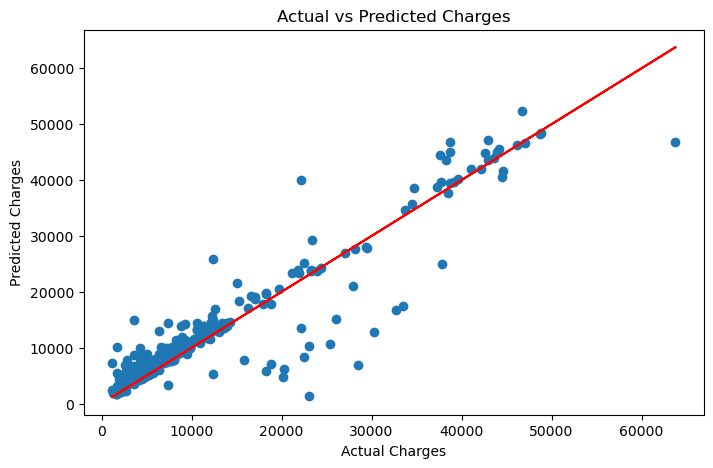

In [80]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, rf_predictions)
plt.plot(y_test, y_test, color= 'red')

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges')

plt.show()

___________________________________
## Model Performance Comparison Visualization
Visual comparison of regression model performance using R² Score.
___________________________________

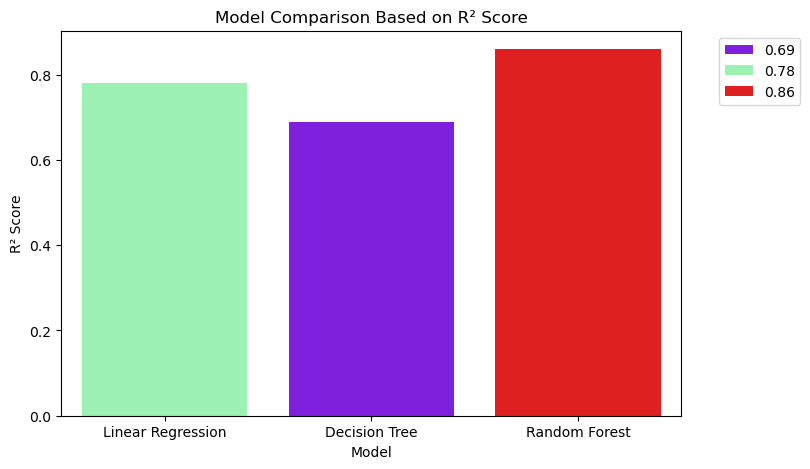

In [81]:
plt.figure(figsize=(8,5))

sns.barplot(x= 'Model', y= 'R² Score', data= comparison, 
            hue= 'R² Score', palette= 'rainbow')

plt.legend(bbox_to_anchor=(1.05,1), loc= 'upper left')
plt.title('Model Comparison Based on R² Score')

plt.show()

___________________________________
# SECTION 13 — Random Forest Feature Importance

* ###  Random Forest Model Interpretation
    * Understanding feature importance using the Random Forest Regressor model.
___________________________________

___________________________________
## Random Forest Feature Importance
Analyzing the most important features affecting insurance charge prediction using the Random Forest Regressor model.
___________________________________

In [82]:
rf_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf_model.feature_importances_
})

rf_importance

,Feature,Importance
0,age,0.132113
1,bmi,0.129391
2,children,0.019091
3,sex_male,0.006549
4,smoker_yes,0.608618
5,region_northwest,0.005498
6,region_southeast,0.005306
7,region_southwest,0.003993
8,age_group_Senior,0.000652
9,age_group_Young,0.001087


___________________________________
## Sorted Random Forest Feature Importance
Sorting features based on their contribution to insurance charge prediction.
___________________________________

In [83]:
rf_importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
4,smoker_yes,0.608618
0,age,0.132113
1,bmi,0.129391
10,bmi_category_Obese,0.084054
2,children,0.019091
3,sex_male,0.006549
5,region_northwest,0.005498
6,region_southeast,0.005306
7,region_southwest,0.003993
11,bmi_category_Overweight,0.003360


___________________________________
## Random Forest Feature Importance Visualization
Visualizing the importance of features affecting insurance charge prediction using the Random Forest Regressor model.
___________________________________

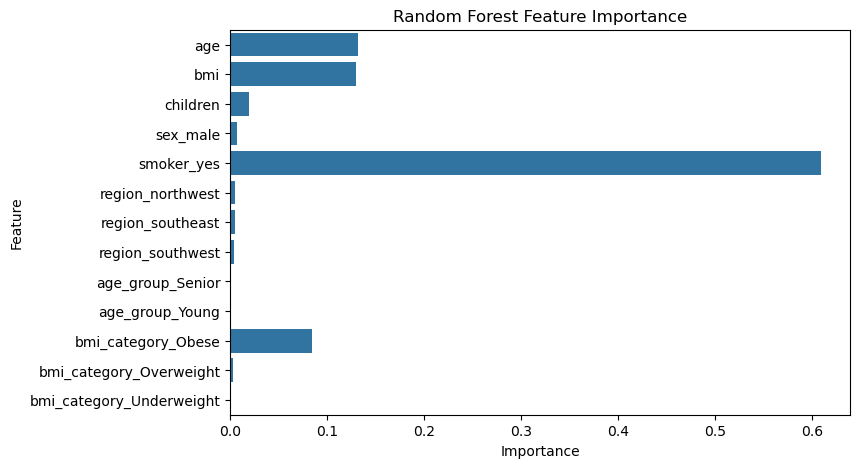

In [84]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=rf_importance)

plt.title("Random Forest Feature Importance")

plt.show()

___________________________________
# Final Business Insight 
**Summarizing the key findings from the medical insurance cost prediction project.**

* Smokers have significantly higher insurance charges.
* Obesity is associated with higher healthcare costs.
* Random Forest Regressor achieved the best prediction performance.
* Age and BMI are important factors affecting insurance charges.
* Machine learning can effectively predict healthcare expenses.
___________________________________

___________________________________
## Final Conclusion
This project successfully analyzed medical insurance data using Python and machine learning techniques. Multiple regression models were trained and compared, with Random Forest Regressor achieving the best performance. The project demonstrates practical skills in data cleaning, exploratory data analysis, data visualization, preprocessing, and predictive modeling.
___________________________________